In [14]:
import sys
import os
# Questo risolve il problema del config.py
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config import (
    PATH_CLEAN_RECIPES,
    PATH_CLEAN_INTERACTIONS
)

# CORREZIONE PERCORSI: Diciamo a Python di partire dalla cartella superiore '..'
# In questo modo 'dataset/clean_recipes.csv' diventa '../dataset/clean_recipes.csv'
PATH_RECIPES_CORRECT = os.path.join('..', PATH_CLEAN_RECIPES)
PATH_INTERACTIONS_CORRECT = os.path.join('..', PATH_CLEAN_INTERACTIONS)

# Ora carichiamo i dati con i percorsi corretti rispetto alla posizione del notebook
df_recipes = pd.read_csv(PATH_RECIPES_CORRECT)
df_interactions = pd.read_csv(PATH_INTERACTIONS_CORRECT)

print(f"Ricette pulite caricate: {df_recipes.shape[0]}")
print(f"Interazioni pulite caricate: {df_interactions.shape[0]}")

Ricette pulite caricate: 15144
Interazioni pulite caricate: 385801


rating
1      1840
2      3876
3     12681
4     59164
5    308240
Name: count, dtype: int64


/tmp/ipykernel_17257/2928163922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_interactions, x='rating', palette='viridis')


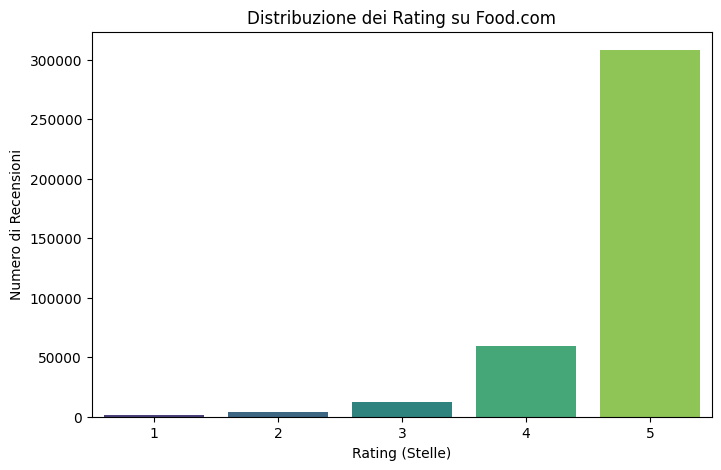

In [15]:
# Conteggio dei singoli voti
rating_counts = df_interactions['rating'].value_counts().sort_index()
print(rating_counts)

# Grafico della distribuzione
plt.figure(figsize=(8, 5))
sns.countplot(data=df_interactions, x='rating', palette='viridis')
plt.title('Distribuzione dei Rating su Food.com')
plt.xlabel('Rating (Stelle)')
plt.ylabel('Numero di Recensioni')
plt.show()

In [16]:
n_users = df_interactions['user_id'].nunique()
n_items = df_interactions['recipe_id'].nunique()
n_interactions = len(df_interactions)

# Calcolo delle medie
interactions_per_user = df_interactions.groupby('user_id').size()
interactions_per_recipe = df_interactions.groupby('recipe_id').size()

print(f"Utenti unici: {n_users} | Ricette uniche: {n_items}")
print(f"Media interazioni per utente: {interactions_per_user.mean():.2f}")
print(f"Media interazioni per ricetta: {interactions_per_recipe.mean():.2f}")

# Calcolo della Sparsità
sparsity = (1 - (n_interactions / (n_users * n_items))) * 100
print(f"Sparsità della matrice: {sparsity:.4f}%")

Utenti unici: 21547 | Ricette uniche: 15144
Media interazioni per utente: 17.91
Media interazioni per ricetta: 25.48
Sparsità della matrice: 99.8818%


Statistiche descrittive delle Calorie:
count    15144.000000
mean       397.750409
std        399.391808
min          0.000000
25%        167.800000
50%        295.200000
75%        479.700000
max       3488.300000
Name: calories, dtype: float64

Numero di ricette sopra le 3000 kcal: 44
                                                    name  calories  minutes
10169                      original praline bacon recipe    3488.3       30
4276   crispy cinnamon streusel banana nut cream chee...    3470.0       75
4552                                   crumbly apple pie    3467.7       85
14573              veronica s lemon buttercream frosting    3446.8       10
2180                               buffalo chicken pizza    3429.6       20
4721                               death by cheese pizza    3395.7       50
14491                                    vanilla walnuts    3394.5       45
410                         another buffalo wings recipe    3394.3       60
13466                       

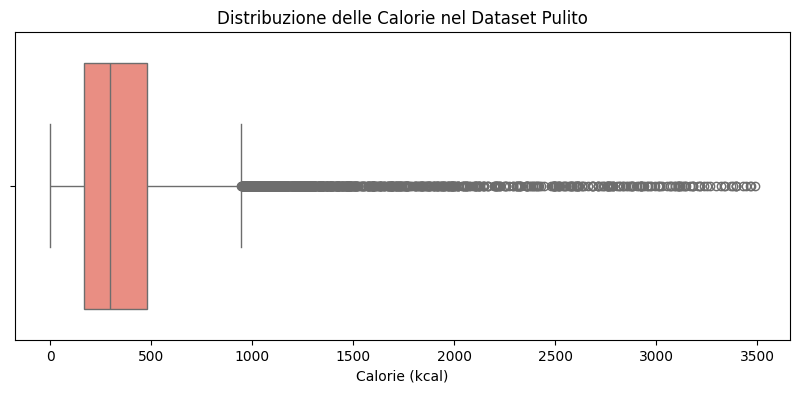

In [17]:
# 3. ANALISI DEI VALORI NUTRIZIONALI (CALORIE)

# Vediamo le statistiche descrittive delle calorie già estratte
print("Statistiche descrittive delle Calorie:")
print(df_recipes['calories'].describe())

# Troviamo le ricette con calorie folli (es. sopra le 3000 kcal)
outliers = df_recipes[df_recipes['calories'] > 3000][['name', 'calories', 'minutes']]
print(f"\nNumero di ricette sopra le 3000 kcal: {len(outliers)}")
print(outliers.sort_values(by='calories', ascending=False).head(10))

# Boxplot visivo degli outlier
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_recipes, x='calories', color='salmon')
plt.title('Distribuzione delle Calorie nel Dataset Pulito')
plt.xlabel('Calorie (kcal)')
plt.show()

In [19]:
# Convertiamo le stringhe in vere liste e "esplodiamo" i tag per contarli
df_recipes['tags_list'] = df_recipes['tags'].apply(lambda x: ast.literal_eval(x))
all_tags = df_recipes['tags_list'].explode()

# Top 20 tag più frequenti
top_20_tags = all_tags.value_counts().head(20)
print("I 20 tag più frequenti nel dataset:")
print(top_20_tags)

I 20 tag più frequenti nel dataset:
tags_list
preparation           15125
time-to-make          14946
course                14476
dietary               12788
main-ingredient       12047
easy                   8853
occasion               8559
equipment              7398
cuisine                6693
low-in-something       6639
main-dish              5158
number-of-servings     4597
60-minutes-or-less     4554
taste-mood             4420
meat                   4366
north-american         4020
vegetables             3881
oven                   3691
30-minutes-or-less     3671
low-carb               3562
Name: count, dtype: int64
